# Regression-Based Robot Current Anomaly Detection
This notebook pulls training data from Neon, trains eight Time-to-Axis regression models, discovers residual thresholds, generates synthetic testing data, and detects sustained Alert/Error events. Zero-current readings are retained as `STOPPED` but excluded from active-current model training.

In [11]:
%load_ext autoreload
%autoreload 2
import sys
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.alert_detection import detect_alerts_and_errors
from src.data_preparation import AXES, prepare_telemetry, zero_reading_summary
from src.database import create_database_engine, load_telemetry_from_database
from src.regression_model import fit_all_axis_models, model_summary
from src.regression_visualization import plot_residual_distribution, plot_test_events, plot_training_regression
from src.synthetic_data import generate_synthetic_test_data, scaling_metadata
from src.synthetic_streaming import stream_synthetic_csv_to_database

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Pull Training Data from Neon PostgreSQL

In [12]:
engine = create_database_engine()
raw = load_telemetry_from_database(engine, 'robot_telemetry', ['Time', *AXES], 'public')
engine.dispose()
prepared = prepare_telemetry(raw)
print(prepared.shape)
display(prepared.head(), prepared['Operating State'].value_counts(), zero_reading_summary(prepared))

(39672, 11)


,Time,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Elapsed Seconds,Operating State
0,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,STOPPED
1,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.812,STOPPED
2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.688,STOPPED
3,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.562,STOPPED
4,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.457,STOPPED


Operating State
STOPPED    25487
ACTIVE     14185
Name: count, dtype: int64

,Axis,Zero Readings,Positive Readings,Missing Readings
0,Axis #1,25914,13758,0
1,Axis #2,25822,13850,0
2,Axis #3,25844,13828,0
3,Axis #4,26004,13668,0
4,Axis #5,25864,13808,0
5,Axis #6,26073,13599,0
6,Axis #7,26010,13662,0
7,Axis #8,25958,13714,0


## 2. Train the Eight Regression Models
For each axis, the input feature `X` is elapsed time in seconds and the target `y` is the positive current reading.

In [13]:
models = fit_all_axis_models(prepared)
summary = model_summary(models)
display(summary.round(4))

,Axis,Training Rows,Slope,Intercept,R Squared,MAE,RMSE,MinC (P95 Positive Residual),MaxC (P99 Positive Residual)
0,Axis #1,13758,-0.0,2.1354,0.0001,2.1489,3.2586,11.6426,19.4674
1,Axis #2,13850,0.0,10.2211,0.0001,5.7168,8.1147,22.0403,34.7305
2,Axis #3,13828,-0.0,7.9129,0.0002,4.0535,5.9644,20.6186,26.6719
3,Axis #4,13668,0.0,1.7686,0.0001,1.4818,2.2526,9.0095,11.9414
4,Axis #5,13808,-0.0,2.7605,0.0000,2.0942,2.7873,8.5015,14.0065
5,Axis #6,13599,0.0,1.7073,0.0001,1.7356,2.7577,11.7826,15.6305
6,Axis #7,13662,0.0,2.4862,0.0001,2.6385,3.0736,5.5912,5.6116
7,Axis #8,13714,0.0,0.2889,0.0000,0.3435,0.6786,3.8250,4.2019


## 3. Examine Regression and Residual Evidence
MinC is the 95th percentile and MaxC is the 99th percentile of positive training residuals.

Regression analysis for Axis #1


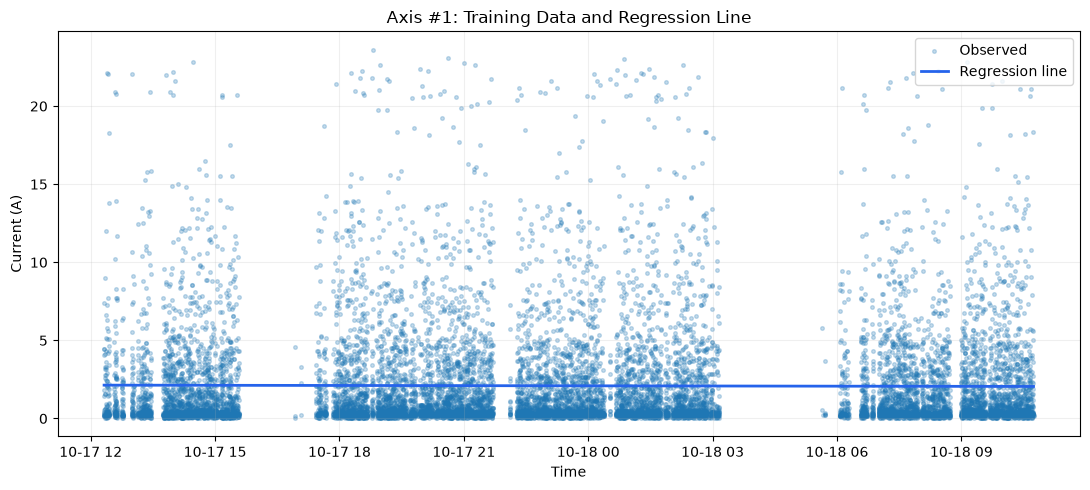

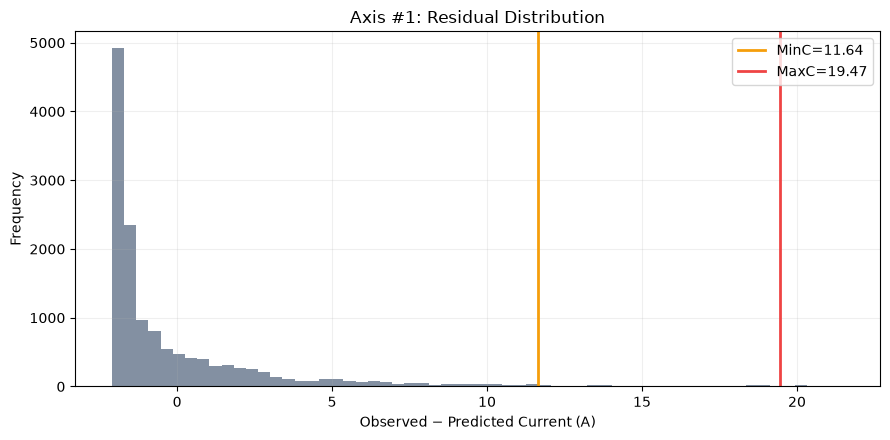

Regression analysis for Axis #2


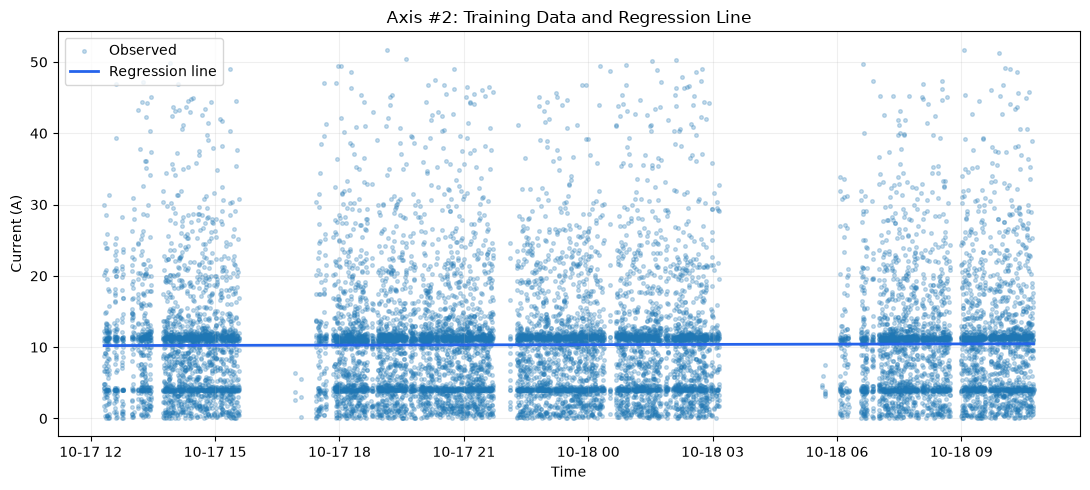

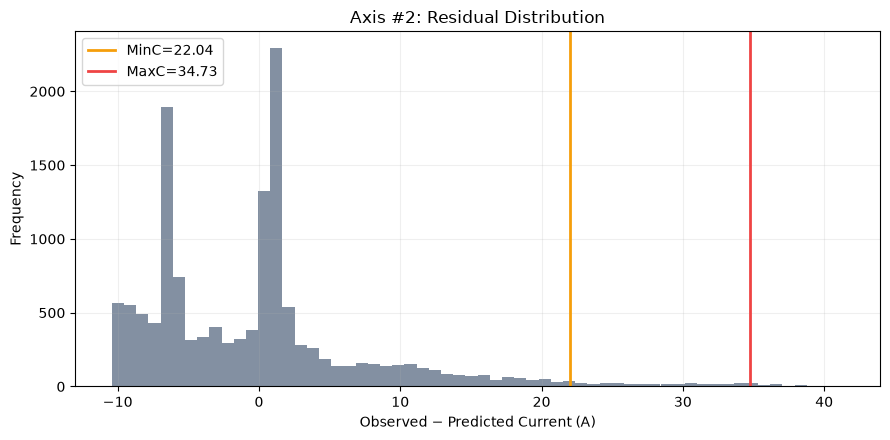

Regression analysis for Axis #3


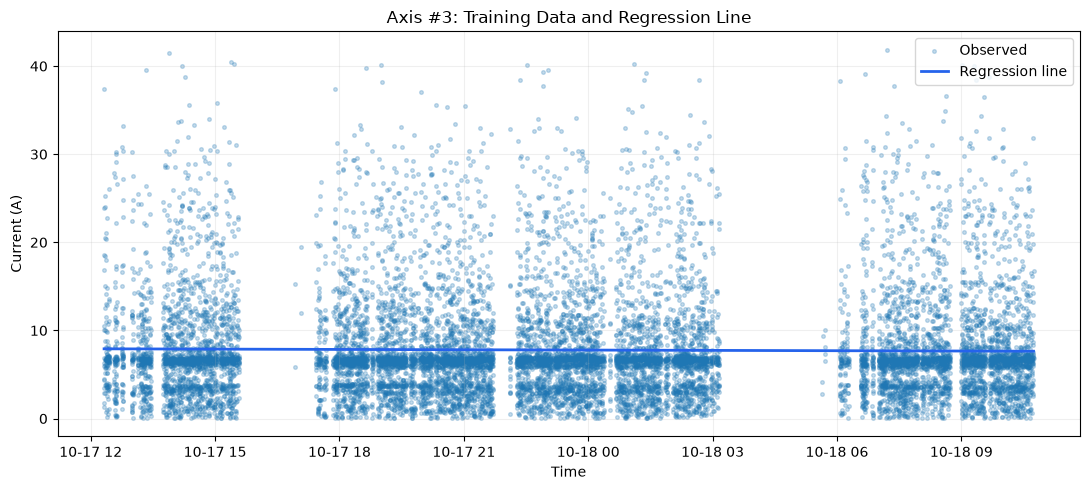

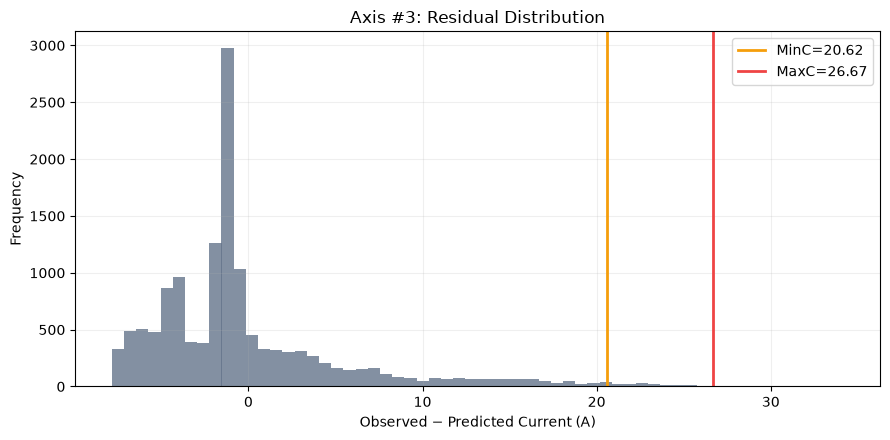

Regression analysis for Axis #4


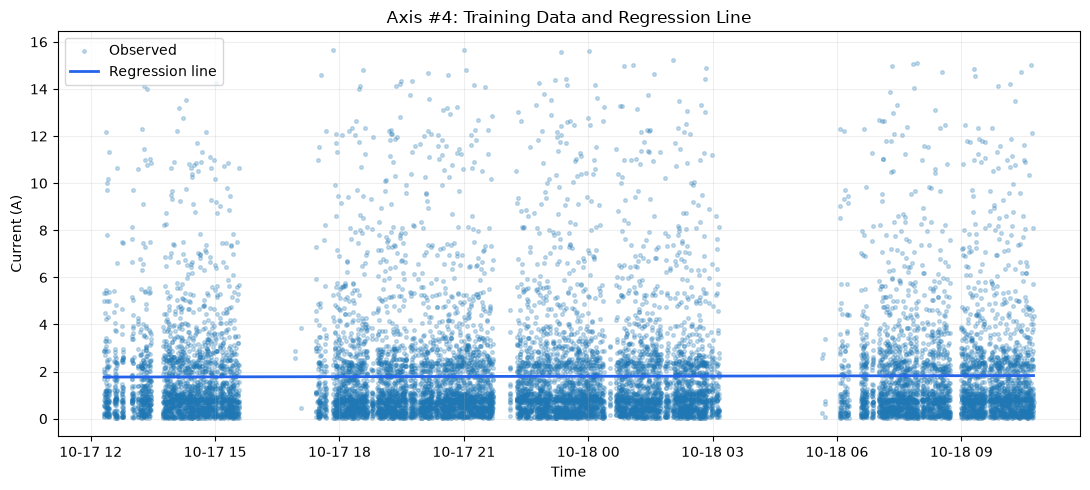

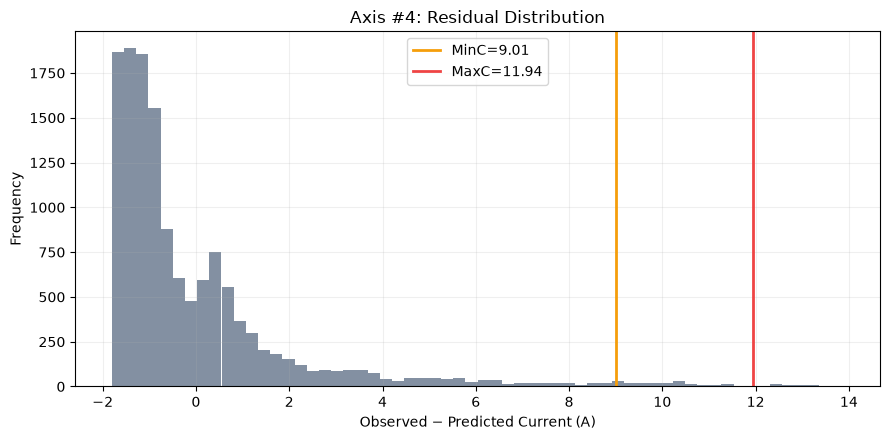

Regression analysis for Axis #5


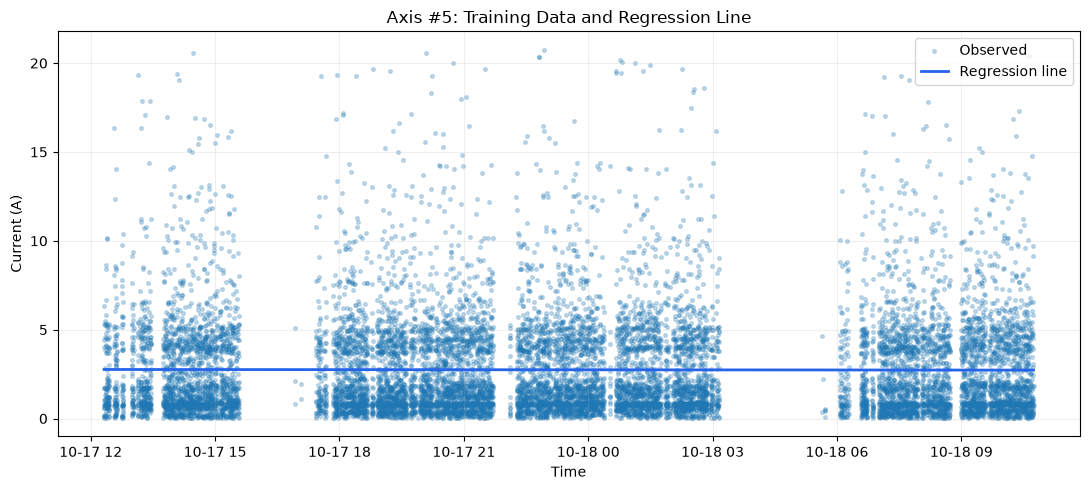

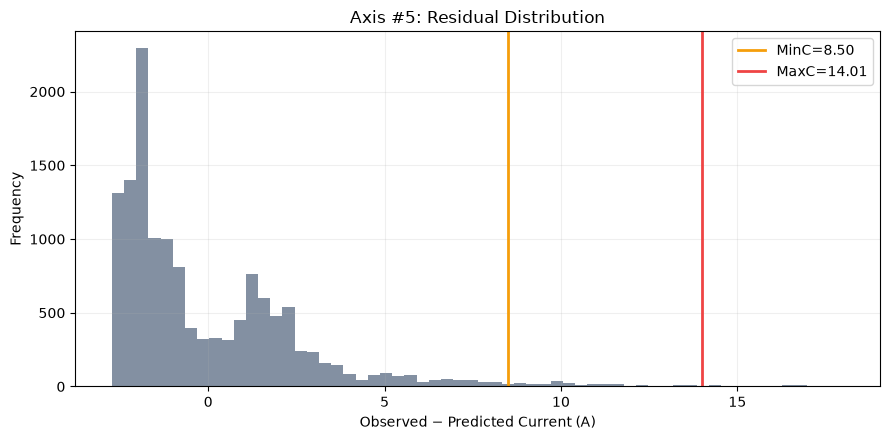

Regression analysis for Axis #6


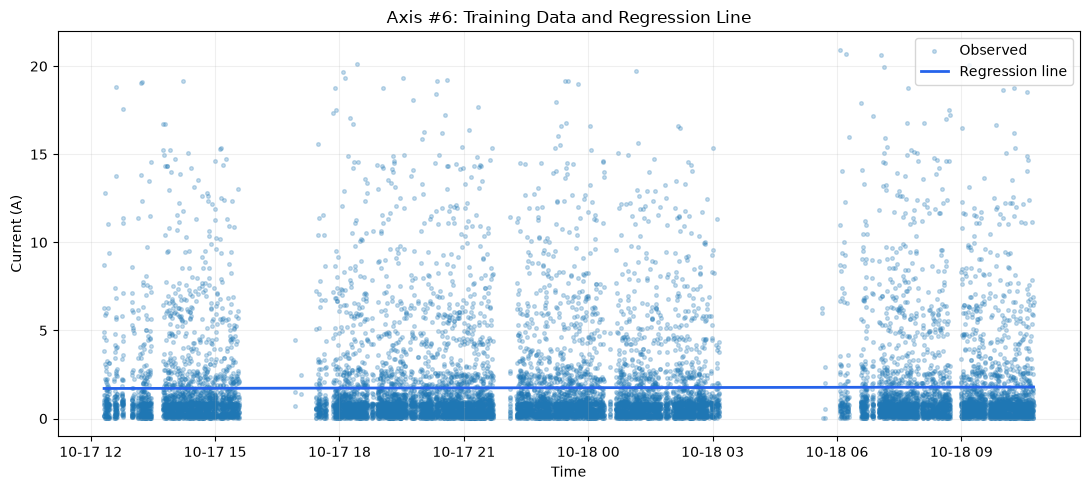

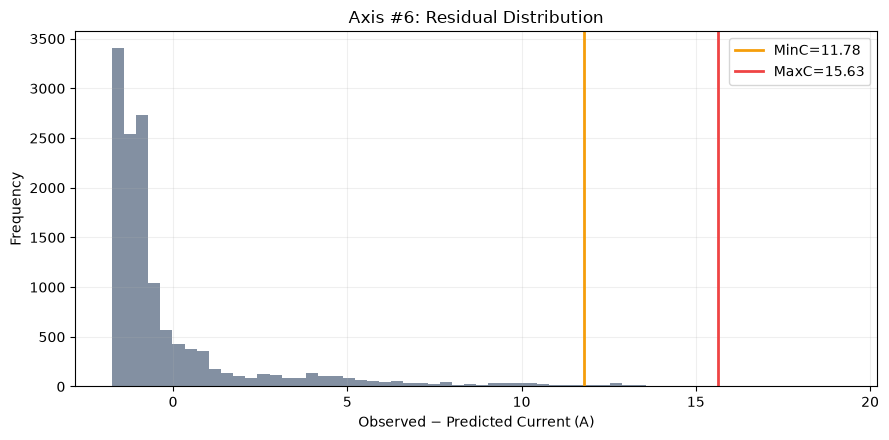

Regression analysis for Axis #7


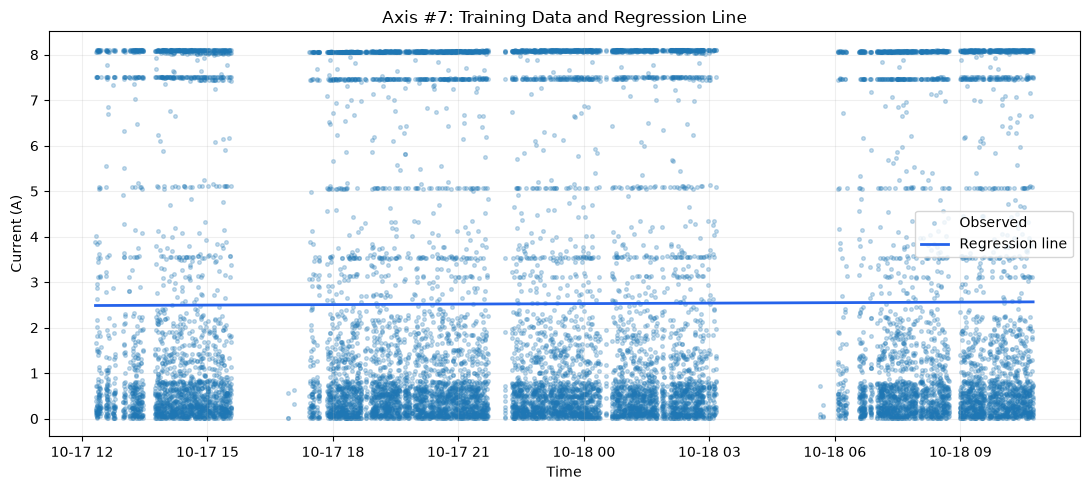

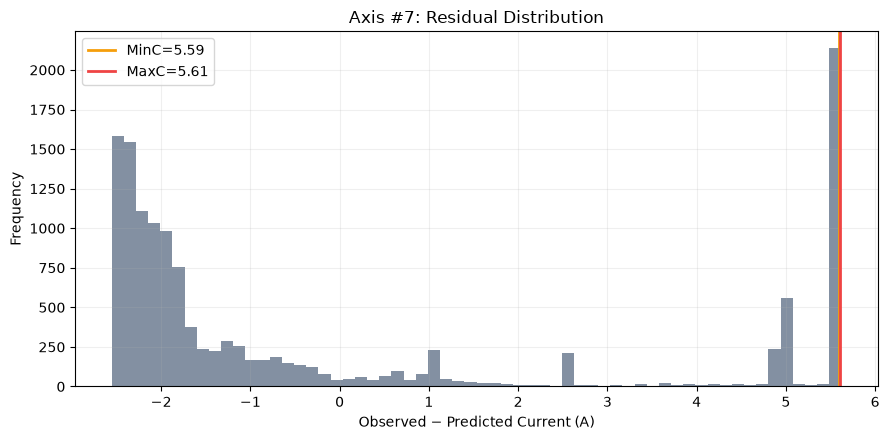

Regression analysis for Axis #8


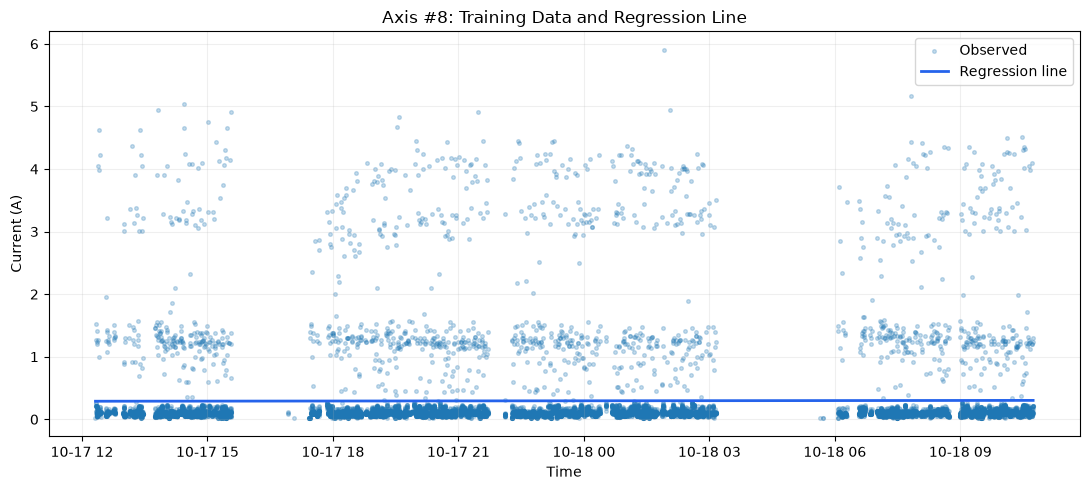

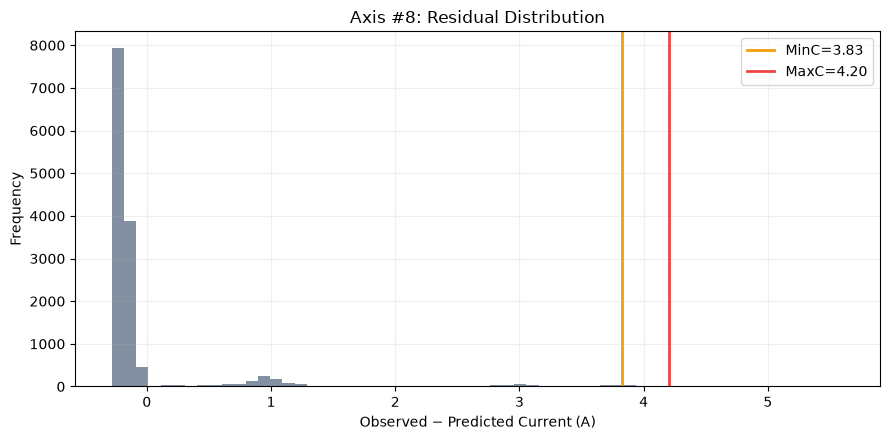

In [14]:
import matplotlib.pyplot as plt

# Display regression and residual analysis for Axis #1 through Axis #8
for axis in AXES:
    print(f"Regression analysis for {axis}")

    regression_figure = plot_training_regression(
        models[axis]
    )
    plt.show()

    residual_figure = plot_residual_distribution(
        models[axis]
    )
    plt.show()

## 4. Generate Synthetic Testing Data and Apply T = 6 Seconds

,Axis,Training Mean,Training Standard Deviation,Training Minimum,Training Maximum,Standardization Formula,Normalization Formula
0,Axis #1,2.0927,3.2587,0.0261,23.6093,(x - training mean) / training std,(x - training min) / (training max - training ...
1,Axis #2,10.3502,8.1150,0.0527,51.7132,(x - training mean) / training std,(x - training min) / (training max - training ...
2,Axis #3,7.7759,5.9649,0.0527,41.8556,(x - training mean) / training std,(x - training min) / (training max - training ...
3,Axis #4,1.8002,2.2527,0.0258,15.6663,(x - training mean) / training std,(x - training min) / (training max - training ...
4,Axis #5,2.7425,2.7873,0.0258,20.7508,(x - training mean) / training std,(x - training min) / (training max - training ...
5,Axis #6,1.7487,2.7578,0.0258,20.9314,(x - training mean) / training std,(x - training min) / (training max - training ...
6,Axis #7,2.5267,3.0737,0.0119,8.1085,(x - training mean) / training std,(x - training min) / (training max - training ...
7,Axis #8,0.2957,0.6787,0.0196,5.9056,(x - training mean) / training std,(x - training min) / (training max - training ...


,Time,Axis #1 Z Score,Axis #1 Normalized,Axis #2 Z Score,Axis #2 Normalized,Axis #3 Z Score,Axis #3 Normalized,Axis #4 Z Score,Axis #4 Normalized,Axis #5 Z Score,Axis #5 Normalized,Axis #6 Z Score,Axis #6 Normalized,Axis #7 Z Score,Axis #7 Normalized,Axis #8 Z Score,Axis #8 Normalized
0,2022-10-18 10:45:00.628000+00:00,-0.642202,0.0,-1.275438,0.0,-1.303606,0.0,-0.799134,0.0,-0.983908,0.0,-0.634089,0.0,-0.82206,0.0,-0.435696,0.0
1,2022-10-18 10:45:02.628000+00:00,-0.642202,0.0,-1.275438,0.0,-1.303606,0.0,-0.799134,0.0,-0.983908,0.0,-0.634089,0.0,-0.82206,0.0,-0.435696,0.0
2,2022-10-18 10:45:04.628000+00:00,-0.642202,0.0,-1.275438,0.0,-1.303606,0.0,-0.799134,0.0,-0.983908,0.0,-0.634089,0.0,-0.82206,0.0,-0.435696,0.0
3,2022-10-18 10:45:06.628000+00:00,-0.642202,0.0,-1.275438,0.0,-1.303606,0.0,-0.799134,0.0,-0.983908,0.0,-0.634089,0.0,-0.82206,0.0,-0.435696,0.0
4,2022-10-18 10:45:08.628000+00:00,-0.642202,0.0,-1.275438,0.0,-1.303606,0.0,-0.799134,0.0,-0.983908,0.0,-0.634089,0.0,-0.82206,0.0,-0.435696,0.0


,Axis,Event,Start Time,End Time,Duration Seconds,Maximum Residual
0,Axis #2,ALERT,2022-10-18 10:47:48.628000+00:00,2022-10-18 10:47:52.628000+00:00,6.0,28.122035
1,Axis #5,ERROR,2022-10-18 10:50:40.628000+00:00,2022-10-18 10:51:02.628000+00:00,24.0,18.663641
2,Axis #8,ERROR,2022-10-18 10:53:40.628000+00:00,2022-10-18 10:53:56.628000+00:00,18.0,4.726872


,Axis,Event,Start Time,End Time,Duration Seconds,Threshold,Maximum Residual
0,Axis #2,ALERT,2022-10-18 10:47:48.628000+00:00,2022-10-18 10:47:52.628000+00:00,6.0,22.040325,28.122035
1,Axis #5,ERROR,2022-10-18 10:50:40.628000+00:00,2022-10-18 10:51:02.628000+00:00,24.0,14.006460,18.663641
2,Axis #8,ERROR,2022-10-18 10:53:40.628000+00:00,2022-10-18 10:53:56.628000+00:00,18.0,4.201931,4.726872


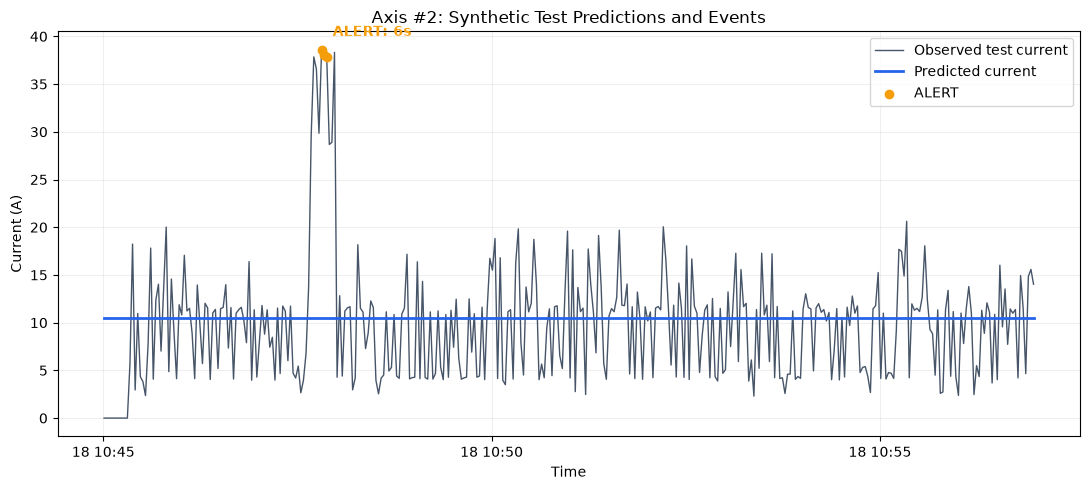

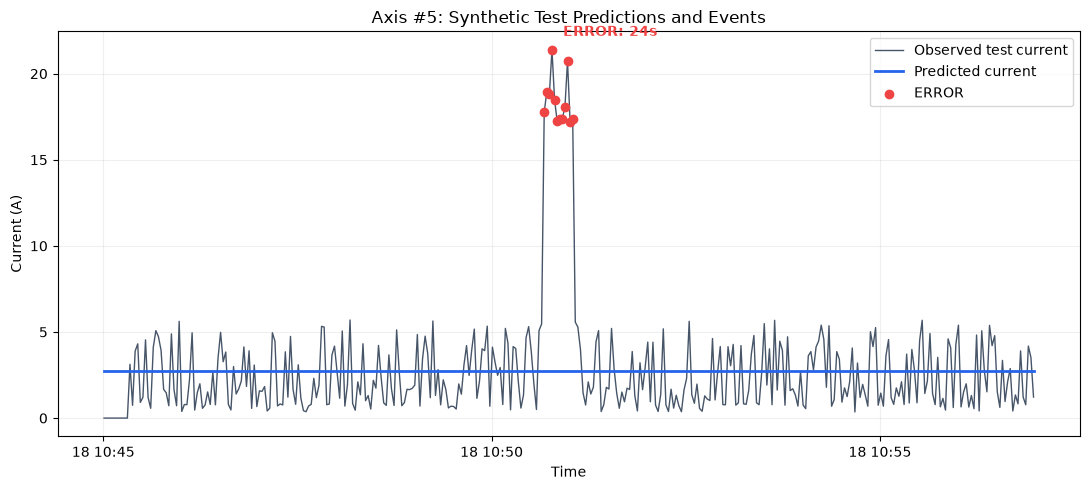

In [20]:
testing = generate_synthetic_test_data(
    prepared,
    models,
    random_state=42
)

testing.to_csv(
    PROJECT_ROOT / "data" / "synthetic_test_data.csv",
    index=False
)

scaling = scaling_metadata(models)

display(scaling.round(4))

display(
    testing.filter(
        regex="Time|Z Score|Normalized"
    ).head()
)

detected, event_log = detect_alerts_and_errors(
    testing,
    models,
    minimum_duration_seconds=6
)

display(
    event_log[
        [
            "Axis",
            "Event",
            "Start Time",
            "End Time",
            "Duration Seconds",
            "Maximum Residual"
        ]
    ]
)

event_log.to_csv(
    PROJECT_ROOT / "data" / "alert_error_log.csv",
    index=False
)

display(event_log)

# One Alert example
alert_figure = plot_test_events(
    detected,
    "Axis #2",
    event_log=event_log
)

# One Error example
error_figure = plot_test_events(
    detected,
    "Axis #5",
    event_log=event_log
)

## 5. Stream Synthetic CSV to PostgreSQL
The generated CSV is replayed chronologically and inserted one row at a time into `synthetic_telemetry_stream`. A short delay keeps the notebook test practical; the production default in the function is two seconds.

In [16]:
stream_engine = create_database_engine()
records_written = stream_synthetic_csv_to_database(
    PROJECT_ROOT / 'data' / 'synthetic_test_data.csv',
    stream_engine,
    table_name='synthetic_telemetry_stream',
    delay_seconds=0.05,
)
stream_engine.dispose()
print('Synthetic rows streamed to PostgreSQL:', records_written)

Synthetic rows streamed to PostgreSQL: 360


## 6. Threshold and Duration Evidence
P95 should leave about 5% of positive training residuals above MinC, while P99 should leave about 1% above MaxC. Testing several duration windows shows why six seconds (approximately three readings) balances sensitivity and false alarms.

In [17]:
threshold_evidence = []
for axis, result in models.items():
    positive = result.residuals.loc[result.residuals['Residual'] > 0, 'Residual']
    threshold_evidence.append({
        'Axis': axis,
        'MinC': result.min_c,
        'Above MinC (%)': positive.ge(result.min_c).mean() * 100,
        'MaxC': result.max_c,
        'Above MaxC (%)': positive.ge(result.max_c).mean() * 100,
    })
display(pd.DataFrame(threshold_evidence).round(3))

duration_evidence = []
for duration in [2, 4, 6, 10]:
    _, events_at_t = detect_alerts_and_errors(testing, models, duration)
    duration_evidence.append({
        'T Seconds': duration,
        'Approximate Consecutive Readings': duration // 2,
        'Alerts': events_at_t['Event'].eq('ALERT').sum() if not events_at_t.empty else 0,
        'Errors': events_at_t['Event'].eq('ERROR').sum() if not events_at_t.empty else 0,
        'Total Events': len(events_at_t),
    })
display(pd.DataFrame(duration_evidence))

,Axis,MinC,Above MinC (%),MaxC,Above MaxC (%)
0,Axis #1,11.643,5.009,19.467,1.002
1,Axis #2,22.040,5.011,34.731,1.013
2,Axis #3,20.619,5.021,26.672,1.014
3,Axis #4,9.010,5.021,11.941,1.022
4,Axis #5,8.502,5.017,14.006,1.018
5,Axis #6,11.783,5.020,15.630,1.004
6,Axis #7,5.591,5.022,5.612,1.014
7,Axis #8,3.825,5.052,4.202,1.038


,T Seconds,Approximate Consecutive Readings,Alerts,Errors,Total Events
0,2,1,3,2,5
1,4,2,2,2,4
2,6,3,1,2,3
3,10,5,0,2,2


## 7. Predictive-Maintenance Interpretation

The regression models estimate the expected current for Axis #1–Axis #8 based on elapsed time. The difference between the observed and predicted current is called the residual.

For each axis:

- **MinC** is the 95th percentile of positive training residuals.
- **MaxC** is the 99th percentile of positive training residuals.
- **T** is the minimum continuous duration required before an event is recorded.

The P95 threshold was selected for Alerts because approximately 5% of positive training residuals exceed it. These readings are unusual but not necessarily critical. The P99 threshold was selected for Errors because only approximately 1% of positive residuals exceed it, indicating a more extreme deviation.

The telemetry is sampled approximately every two seconds. Therefore:

- T = 2 seconds requires approximately one unusual reading.
- T = 4 seconds requires approximately two consecutive unusual readings.
- T = 6 seconds requires approximately three consecutive unusual readings.
- T = 10 seconds requires approximately five consecutive unusual readings.

T = 6 seconds was selected because it reduces alerts caused by isolated current spikes while still detecting sustained abnormal behaviour early enough for predictive maintenance.

In the synthetic test run:

- T = 2 seconds produced 5 events.
- T = 4 seconds produced 4 events.
- T = 6 seconds produced 3 events.
- T = 10 seconds produced 2 events.

The selected six-second window produced one Alert and two Errors. An Alert indicates that maintenance personnel should inspect the affected axis. An Error represents a more extreme sustained deviation and should receive urgent maintenance attention.

Zero readings are classified as STOPPED rather than anomalous because they represent periods when the robot is not operating. This prevents normal stopped periods from creating false maintenance events.